# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# Proyek Akhir: Prediksi Kelangsungan Hidup Penumpang Titanic

### Perkenalan Dataset
* **Nama Dataset:** Titanic - Machine Learning from Disaster
* **Sumber Dataset:** [Kaggle - Titanic Dataset](https://www.kaggle.com/c/titanic)
* **Deskripsi Singkat:** Dataset ini berisi data historis penumpang kapal Titanic, termasuk informasi seperti umur, jenis kelamin, kelas tiket, harga tiket, dan status keselamatan mereka (Survived atau Not Survived). Tujuan dari proyek ini adalah membangun model machine learning yang dapat memprediksi apakah seorang penumpang akan selamat dari tragedi tersebut berdasarkan fitur-fitur yang tersedia.

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Mengabaikan warnings agar output notebook lebih bersih
import warnings
warnings.filterwarnings('ignore')

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
# Memuat dataset titanic bawaan dari seaborn
df = sns.load_dataset('titanic')

# Menampilkan 5 baris pertama untuk memastikan data berhasil dimuat
display(df.head())

# Mengecek informasi struktur data dan jumlah nilai kosong awal
df.info()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

Jumlah Missing Values per Kolom:
 survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


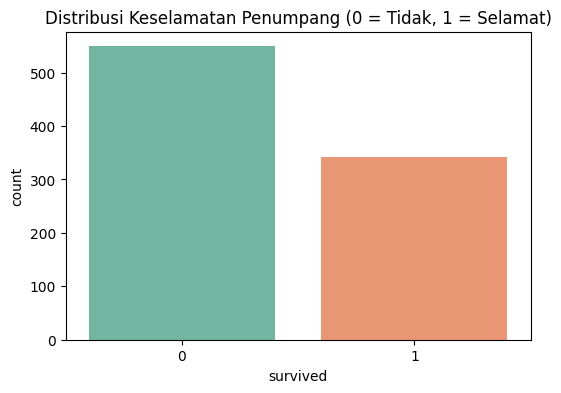

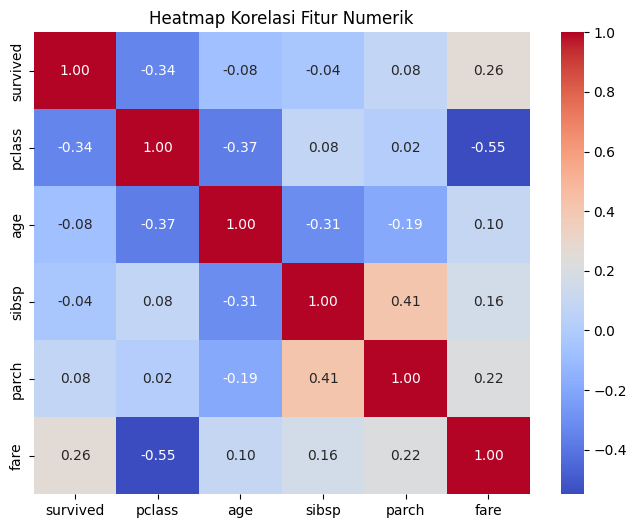

In [3]:
# 1. Mengecek jumlah missing values di setiap kolom
print("Jumlah Missing Values per Kolom:\n", df.isnull().sum())

# 2. Visualisasi sebaran data yang selamat (Survived)
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='survived', palette='Set2')
plt.title('Distribusi Keselamatan Penumpang (0 = Tidak, 1 = Selamat)')
plt.show()

# 3. Heatmap Korelasi antar fitur numerik
plt.figure(figsize=(8, 6))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap Korelasi Fitur Numerik')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [4]:
# 1. Menghapus kolom yang redundan atau terlalu banyak missing values
# (Misal: 'deck' terlalu banyak kosong, 'alive' sama dengan 'survived')
df_clean = df.drop(columns=['deck', 'alive', 'class', 'who', 'adult_male', 'embark_town'])

# 2. Menangani Missing Values
# Mengisi umur yang kosong dengan nilai median
df_clean['age'].fillna(df_clean['age'].median(), inplace=True)
# Mengisi pelabuhan keberangkatan (embarked) dengan modus
df_clean['embarked'].fillna(df_clean['embarked'].mode()[0], inplace=True)

# 3. Encoding Data Kategorikal
label_cols = ['sex', 'embarked', 'alone']
le = LabelEncoder()
for col in label_cols:
    df_clean[col] = le.fit_transform(df_clean[col])

# 4. Memisahkan Fitur (X) dan Target (y)
X = df_clean.drop(columns=['survived'])
y = df_clean['survived']

# 5. Normalisasi/Standarisasi Fitur Numerik
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Mengembalikan ke bentuk DataFrame agar mudah dibaca
X_final = pd.DataFrame(X_scaled, columns=X.columns)

print("Data Preprocessing Selesai! Ukuran data akhir:", X_final.shape)
display(X_final.head())

Data Preprocessing Selesai! Ukuran data akhir: (891, 8)


,pclass,sex,age,sibsp,parch,fare,embarked,alone
0,0.827377,0.737695,-0.565736,0.432793,-0.473674,-0.502445,0.585954,-1.231645
1,-1.566107,-1.355574,0.663861,0.432793,-0.473674,0.786845,-1.942303,-1.231645
2,0.827377,-1.355574,-0.258337,-0.474545,-0.473674,-0.488854,0.585954,0.811922
3,-1.566107,-1.355574,0.433312,0.432793,-0.473674,0.420730,0.585954,-1.231645
4,0.827377,0.737695,0.433312,-0.474545,-0.473674,-0.486337,0.585954,0.811922


In [6]:
# Menyimpan hasil preprocessing ke dalam berkas CSV
df.to_csv('titanic_preprocessed.csv', index=False)
print("Hasil preprocessing berhasil diexport ke berkas CSV!")

Hasil preprocessing berhasil diexport ke berkas CSV!
